# Pruning 

# 2- Structured Pruning 

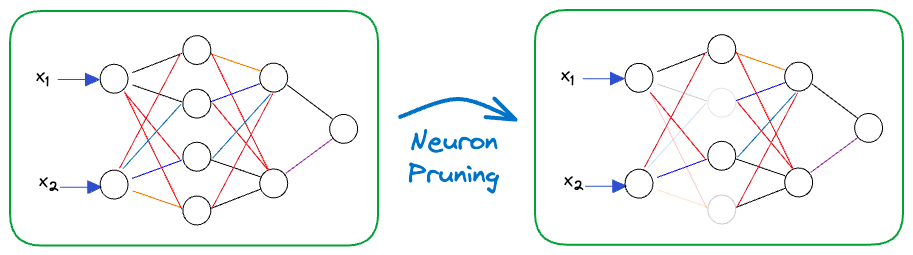 

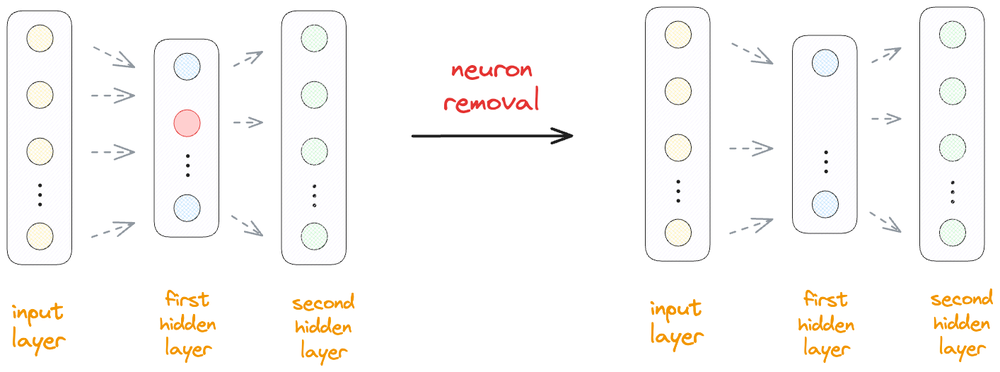

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.nn.utils import prune
import random

# ----------------------------
# Repro + device
# ----------------------------
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Device: cuda


In [2]:
# ----------------------------
# Data (MNIST)
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True if device.type=="cuda" else False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True if device.type=="cuda" else False)


In [3]:

# ----------------------------
# Tiny MLP
# ----------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP().to(device)



In [4]:
# ----------------------------
# Train / Eval helpers
# ----------------------------
def train_one_epoch(model, loader, opt):
    model.train()
    total, correct, total_loss = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct/total, total_loss/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    # Get the device from the model's parameters
    model_device = next(model.parameters()).device
    for x, y in loader:
        x, y = x.to(model_device), y.to(model_device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct/total, total_loss/total


In [5]:

# ----------------------------
# Baseline training
# ----------------------------
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
baseline_epochs = 1  # keep small for speed
for ep in range(baseline_epochs):
    tr_acc, tr_loss = train_one_epoch(model, train_loader, opt)
    te_acc, te_loss = evaluate(model, test_loader)
    print(f"[Baseline] Epoch {ep+1}/{baseline_epochs} | Train acc {tr_acc:.4f} loss {tr_loss:.4f} | Test acc {te_acc:.4f} loss {te_loss:.4f}")


[Baseline] Epoch 1/1 | Train acc 0.9198 loss 0.2716 | Test acc 0.9638 loss 0.1183


In [6]:

# ----------------------------
# Measure sparsity (helper)
# ----------------------------
def layer_sparsity(tensor):
    num_zeros = (tensor == 0).sum().item()
    numel = tensor.numel()
    return num_zeros / numel

def report_sparsity(model):
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear):
            w = m.weight
            print(f"Layer {name}: weight sparsity = {layer_sparsity(w.data):.3f} | shape {tuple(w.shape)}")
    # overall (Linear-only)
    all_w = torch.cat([m.weight.detach().flatten() for m in model.modules() if isinstance(m, nn.Linear)])
    overall = (all_w == 0).sum().item() / all_w.numel()
    print(f"Overall sparsity (Linear layers): {overall:.3f}")

print("\nSparsity BEFORE pruning (should be ~0.0):")
report_sparsity(model)




Sparsity BEFORE pruning (should be ~0.0):
Layer fc1: weight sparsity = 0.000 | shape (256, 784)
Layer fc2: weight sparsity = 0.000 | shape (128, 256)
Layer fc3: weight sparsity = 0.000 | shape (10, 128)
Overall sparsity (Linear layers): 0.000


In [7]:
# -------------------------------------------------------

# STRUCTURED PRUNING: prune 30% of neurons in fc2 (whole rows)

# -------------------------------------------------------
amount_struct = 0.30
prune.ln_structured(model.fc2, name="weight", amount=amount_struct, n=2, dim=0)

with torch.no_grad():
    fc2_row_keep = (model.fc2.weight_mask.sum(dim=1) > 0).to(dtype=torch.float32)
prune.CustomFromMask.apply(model.fc2, name="bias", mask=fc2_row_keep)

print(f"\nApplied STRUCTURED pruning on fc2 rows (amount={amount_struct:.0%}).")

kept = int(fc2_row_keep.sum().item())
print(f"fc2 neurons kept: {kept}/{model.fc2.out_features}")

# Check test right after pruning
te_acc_sp, te_loss_sp = evaluate(model, test_loader)
print(f"[Structured] Immediately after pruning: acc {te_acc_sp:.4f}, loss {te_loss_sp:.4f}")

# Brief fine-tune to recover
opt_sp = torch.optim.Adam(model.parameters(), lr=5e-4)
for ep in range(1):
    tr_acc, tr_loss = train_one_epoch(model, train_loader, opt_sp)
    te_acc, te_loss = evaluate(model, test_loader)
    print(f"[Structured-FT] Epoch {ep+1}/1 | Train acc {tr_acc:.4f} loss {tr_loss:.4f} | Test acc {te_acc:.4f} loss {te_loss:.4f}")

# Make permanent (remove reparam/mask -> real zero rows)
if hasattr(model.fc2, "weight_mask"): prune.remove(model.fc2, "weight")
if hasattr(model.fc2, "bias_mask"):   prune.remove(model.fc2, "bias")
print("Structured pruning made permanent on fc2.")


Applied STRUCTURED pruning on fc2 rows (amount=30%).
fc2 neurons kept: 90/128
[Structured] Immediately after pruning: acc 0.9637, loss 0.1270
[Structured-FT] Epoch 1/1 | Train acc 0.9702 loss 0.1011 | Test acc 0.9725 loss 0.0894
Structured pruning made permanent on fc2.


In [8]:
import os, copy

# 1) Save ORIGINAL (before compaction)
orig_model = copy.deepcopy(model)
torch.save(orig_model.state_dict(), "mnist_mlp_precompact.pth")

# VERY IMPORTANT NOTE: 

One important caveat here is that Pruning, by itself, does not reduce memory footprint or make inference faster, because the tensors remain the same size and most deep-learning libraries still use dense matrix multiplications.

To actually gain speed and memory improvements, you need to go further:

- Structured pruning + layer compaction: rebuild layers with fewer neurons/channels after pruning (e.g., fc2: 256→128 becomes 256→90, say).

- Sparse-aware kernels: run inference with libraries/hardware that skip zeros (e.g., cuSPARSE, NVIDIA Ampere 2:4 structured sparsity).

- Sparse storage techniques (e.g., CSR format)

In [9]:
@torch.no_grad()
def compact_fc2_fc3(model, keep_mask_bool):
    """Shrink fc2 rows (out_features) + fc3 columns (in_features) using keep_mask."""
    device = next(model.parameters()).device
    old_fc2, old_fc3 = model.fc2, model.fc3
    keep_idx = keep_mask_bool.nonzero(as_tuple=False).squeeze(1).cpu()
    new_out = keep_idx.numel()

    new_fc2 = nn.Linear(old_fc2.in_features, new_out, bias=True)
    new_fc3 = nn.Linear(new_out, old_fc3.out_features, bias=True)

    new_fc2.weight.copy_(old_fc2.weight[keep_idx])
    new_fc2.bias.copy_(old_fc2.bias[keep_idx])
    new_fc3.weight.copy_(old_fc3.weight[:, keep_idx])
    new_fc3.bias.copy_(old_fc3.bias)

    model.fc2 = new_fc2.to(device)
    model.fc3 = new_fc3.to(device)
    return new_out

def count_params(model): return sum(p.numel() for p in model.parameters())

before = count_params(model)
kept = compact_fc2_fc3(model, fc2_row_keep.bool())
after  = count_params(model)
print(f"[Compaction] fc2 -> {kept} neurons | params: {before:,} -> {after:,}")

te_acc, te_loss = evaluate(model, test_loader)
print(f"[After compaction] Test acc {te_acc:.4f} loss {te_loss:.4f}")

[Compaction] fc2 -> 90 neurons | params: 235,146 -> 225,000
[After compaction] Test acc 0.9725 loss 0.0894


In [ ]:
# 2) Save COMPACT (after compaction)
torch.save(model.state_dict(), "mnist_mlp_compact.pth")

# 3) Compare
def fsz(p):
    return os.path.getsize(p)/1024

print(f"File size (KB): precompact={fsz('mnist_mlp_precompact.pth'):.1f} | compact={fsz('mnist_mlp_compact.pth'):.1f}")
print(f"Compression ratio: {fsz('mnist_mlp_precompact.pth')/fsz('mnist_mlp_compact.pth'):.2f}x")

File size (KB): precompact=921.7 | compact=882.0
Compression ratio: 1.05x
